In [1]:
import pandas as pd
import numpy as np
import socket
from DATA.stock_invest_function import *

In [2]:

# DB 접속 정보 설정
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    'host': get_db_host(),
    # 'host': 'hystox74.synology.me',         # 예: 'localhost' 또는 IP
    'port': '3307',              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}

trade_df = fetch_table_data(db_info, "us_trade_quarter_data_with_forecast")

# date를 datetime으로 변환
trade_df['date'] = pd.to_datetime(trade_df['date'])

# pivot table 생성
trade_pivot_df = trade_df.pivot_table(index='date', columns='hs_code_6d', values='expDlr')

# YoY 성장률 계산 (4분기 전 대비), 경고 방지
yoy_trade_growth = trade_pivot_df.pct_change(periods=4, fill_method=None) * 100

✅ 'us_trade_quarter_data_with_forecast' 테이블에서 4969건의 데이터를 가져왔습니다.


In [3]:
fs_df = fetch_table_data(db_info, "US_fundq")

# 0. 사전 준비
df = fs_df.copy()

# 1. 날짜 컬럼 정제
df['date'] = pd.to_datetime(df['date'])

# 2. 분기 종료일 기준으로 집계
df['quarter'] = df['date'].dt.to_period('Q').dt.to_timestamp(how='end')

# 3. 원하는 재무 변수만 선택
target_vars = ['saleq']
id_var = 'tic'  # 고유 기업 식별자
value_vars = [col for col in df.columns if col in target_vars]

# 4. 필요한 열만 추출하고 결측 제외
df_filtered = df[['quarter', id_var] + value_vars].dropna(subset=value_vars, how='all')

# 5. 긴 형태로 변환
df_long = df_filtered.melt(
    id_vars=['quarter', id_var],
    value_vars=value_vars,
    var_name='metric',
    value_name='value'
)

# 6. 피벗: (행: quarter, 열: (tic, metric), 값: value)
pivot_df = df_long.pivot_table(index='quarter', columns=[id_var, 'metric'], values='value')

# 7. 전년 동분기 대비 증가율 계산
yoy_growth = pivot_df.pct_change(periods=4, fill_method=None) * 100

# 8. index를 YYYY-MM-DD 문자열로 변경
yoy_growth.index = yoy_growth.index.strftime('%Y-%m-%d')

# 9. 컬럼명이 MultiIndex일 경우, 'tic'만 남기기
if isinstance(yoy_growth.columns, pd.MultiIndex):
    yoy_growth.columns = yoy_growth.columns.get_level_values(0)

# 결과
yoy_sales_growth = yoy_growth

✅ 'US_fundq' 테이블에서 1572228건의 데이터를 가져왔습니다.


In [4]:
def compute_cross_correlation(yoy_trade_growth, yoy_sales_growth, start_date, end_date):
    # 1. 날짜 인덱스를 datetime 형식으로 통일
    yoy_trade_growth.index = pd.to_datetime(yoy_trade_growth.index)
    yoy_sales_growth.index = pd.to_datetime(yoy_sales_growth.index)

    # 2. 날짜 범위 필터링
    trade_filtered = yoy_trade_growth.loc[start_date:end_date]
    sales_filtered = yoy_sales_growth.loc[start_date:end_date]

    # 3. 공통 인덱스만 사용
    common_index = trade_filtered.index.intersection(sales_filtered.index)
    trade_filtered = trade_filtered.loc[common_index]
    sales_filtered = sales_filtered.loc[common_index]

    # 4. 결측치 제거: 동일한 인덱스를 갖는 두 데이터프레임에 대해,
    #    각 조합마다 NaN 이 없는 시점만 추출
    # 교차 상관계수 계산을 위한 빈 결과 df 생성
    result = pd.DataFrame(index=trade_filtered.columns, columns=sales_filtered.columns, dtype=float)

    # 5. HS코드(h)와 Ticker(t)별로 상관계수 계산
    for h in trade_filtered.columns:
        for t in sales_filtered.columns:
            merged = pd.concat([trade_filtered[h], sales_filtered[t]], axis=1).dropna()
            if len(merged) > 1:  # 상관계수 계산을 위해 최소 2개 이상 필요
                result.at[h, t] = merged.corr().iloc[0, 1]

    return result

# 사용 예시
start_date = '2020-01-01'
end_date = '2024-12-31'

correlation_result = compute_cross_correlation(yoy_trade_growth, yoy_sales_growth, start_date, end_date)

In [5]:
correlation_result.dropna(axis=1)

tic,A,AA,AAL,AAN,AAOI,AAON,AAP,AAPL,ABBV,ABEO,...,ZS,ZTEK,ZTS,ZUMZ,ZUO,ZVIA,ZVRA,ZWS,ZYME,ZYXI
hs_code_6d,,,,,,,,,,,,,,,,,,,,,
100199,0.567871,0.620442,0.254399,0.484440,0.266144,-0.168655,0.836255,0.546288,0.557973,-0.583900,...,0.433313,0.197017,0.396761,0.366010,0.168087,0.229275,-0.392984,-0.417909,-0.074053,0.354055
100590,0.534700,0.468208,-0.142563,-0.219303,0.269002,-0.653070,0.727380,0.813799,0.880415,-0.424871,...,0.307158,0.807463,0.727056,0.629521,0.105785,-0.387746,0.270681,-0.660909,-0.368387,0.564172
120190,0.162300,0.190038,-0.127203,0.499700,0.415037,0.199062,0.465235,-0.030058,0.393720,-0.374384,...,0.482271,-0.100396,-0.110922,-0.123250,-0.184937,0.563049,-0.392013,0.049744,0.057601,0.131078
210690,0.301832,0.634655,0.268288,-0.569714,-0.162395,-0.667813,0.379289,0.661832,0.367739,-0.323201,...,-0.061988,0.422918,0.820234,0.623746,0.256732,-0.835720,0.182522,-0.675512,-0.390830,0.060212
230330,0.764107,0.605396,0.280659,0.236408,0.069921,-0.243506,0.602906,0.781020,0.570906,-0.179168,...,0.683480,-0.060023,0.712874,0.744824,0.203347,0.741535,0.104030,-0.599428,-0.232853,0.460518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903141,0.145172,0.418080,0.458506,0.274676,-0.299607,0.213055,0.155766,0.109922,-0.235289,-0.481396,...,0.078442,0.248902,0.126421,0.060564,0.146262,0.120682,-0.322185,0.027000,0.235323,-0.359347
903180,0.109137,0.301485,0.463943,0.234430,-0.228578,0.476177,-0.222811,-0.097842,-0.510832,0.474764,...,0.178144,-0.329796,-0.000861,0.096634,-0.002632,0.086785,-0.203901,0.214649,0.290690,-0.596076
970191,0.731332,-0.799098,0.778233,0.647629,0.078263,0.911705,-0.251821,-0.732015,-0.633254,0.454317,...,0.891059,-0.681536,-0.888354,-0.913897,0.916530,0.750908,0.196880,0.871695,0.767844,0.755458


In [16]:
def get_top_correlated_hscode(corr_matrix, symbol, top_n=5, threshold=None, ascending=False):
    """
    특정 기업(Symbol)에 대해 상관관계가 높은 HS 코드를 추출하는 함수
    corr_matrix: HS_code x Symbol 구조로 되어 있어야 함 (자동 전치 처리 포함)
    """
    # 전치하여 symbol을 index로 만듦
    corr_matrix_T = corr_matrix.T

    if symbol not in corr_matrix_T.index:
        raise ValueError(f"Symbol '{symbol}' not found in correlation matrix.")

    symbol_corr = corr_matrix_T.loc[symbol].dropna()

    if threshold is not None:
        symbol_corr = symbol_corr[symbol_corr >= threshold]

    top_correlated = symbol_corr.sort_values(ascending=ascending).head(top_n)

    return top_correlated.reset_index().rename(columns={'index': 'root_hs_code', symbol: 'correlation'})

def get_top_correlated_symbols_by_row(corr_matrix, hs_code, top_n=5, threshold=None, ascending=False):
    """
    특정 HS 코드(행 기준)에 대해 상관관계가 높은 기업(Symbol, 컬럼)을 추출하는 함수 (상관계수 1.0은 제거)

    Parameters:
    - corr_matrix (pd.DataFrame): HS_Code x Symbol 형태의 상관관계 행렬
    - hs_code (str or int): 대상 HS 코드 (예: '841199')
    - top_n (int): 상위 N개 추출
    - threshold (float or None): 상관계수 하한값
    - ascending (bool): 낮은 값부터 정렬할지 여부 (False = 높은 순)

    Returns:
    - pd.DataFrame: symbol 및 correlation 정보를 담은 상위 N개 결과
    """
    hs_code_str = str(hs_code)

    if hs_code_str not in corr_matrix.index.astype(str):
        raise ValueError(f"HS code '{hs_code}' not found in correlation matrix index.")

    actual_index = [idx for idx in corr_matrix.index if str(idx) == hs_code_str][0]
    row_corr = corr_matrix.loc[actual_index].dropna()

    # 상관계수 1.0 제거 (정밀 비교)
    row_corr = row_corr[~np.isclose(row_corr, 1.0)]

    # threshold 필터 적용
    if threshold is not None:
        row_corr = row_corr[row_corr >= threshold]

    top_symbols = row_corr.sort_values(ascending=ascending).head(top_n)

    result_df = top_symbols.reset_index()
    result_df.columns = ['symbol', 'correlation']

    return result_df

In [148]:
top_symbols = get_top_correlated_symbols_by_row(
    corr_matrix=correlation_result,
    hs_code= '842129',
    top_n=500,
    threshold=0.60  # 선택사항
)

print(top_symbols.iloc[0:21])

   symbol  correlation
0   CRXTQ     0.987739
1     MSP     0.987151
2    CNVY     0.979128
3   PEARQ     0.975087
4   GEENQ     0.972406
5   CHAPQ     0.972087
6     DEN     0.971212
7     XOG     0.969701
8       D     0.961302
9     CTB     0.955122
10   ARNC     0.953954
11   JEWL     0.953871
12   VLTA     0.953733
13   LSEA     0.952349
14  BRDSQ     0.952037
15    MGY     0.950401
16   WEBR     0.945412
17   OLPX     0.945290
18   PRST     0.943947
19   LTCH     0.939760
20   MOBQ     0.938869


In [115]:
print(top_symbols.iloc[281:301])

    symbol  correlation
281     EW     0.704451
282   DELL     0.704381
283   VIVE     0.704287
284   CVLT     0.703840
285   SCCO     0.703639
286   BLDR     0.703469
287  HCDIQ     0.702737
288   QRVO     0.702697
289  IVCRQ     0.701414
290    DCT     0.700735
291  EXPRQ     0.700216
292   AVTR     0.699896
293    HCA     0.699847
294   AONC     0.699662
295    KIN     0.699209
296   ALHC     0.699102
297    PKG     0.697469
298   AXAS     0.697093
299  POLCQ     0.696995


In [149]:
top_hs_codes = get_top_correlated_hscode(
    corr_matrix=correlation_result,  # 이전에 만든 상관관계 행렬
    symbol='DCI',
    top_n=40,
    threshold=0.2  # 선택사항
)

print(top_hs_codes)

   hs_code_6d  correlation
0      290110     0.920849
1      854442     0.916605
2      853690     0.888309
3      901839     0.875767
4      988000     0.844383
5      271012     0.836964
6      880000     0.814003
7      270900     0.803182
8      271019     0.783169
9      392690     0.779019
10     470321     0.766532
11     271311     0.764850
12     270112     0.761764
13     901890     0.755183
14     271112     0.754426
15     390110     0.751412
16     853890     0.747619
17     390410     0.735595
18     391990     0.724119
19     330499     0.722487
20     710391     0.713007
21     390120     0.697610
22     842129     0.693519
23     902790     0.690381
24     740400     0.677207
25     230910     0.667441
26     711319     0.662867
27     902190     0.660145
28     853710     0.650624
29     710239     0.629954
30     271111     0.625288
31     330210     0.624766
32     854430     0.623042
33     732690     0.622278
34     903141     0.604101
35     854239     0.599886
3

In [159]:
# 수출 증가율 조회
ticker = 'ECL'
hs_cd = '842129'
correlation_result.loc[hs_cd][[ticker]]



tic
ECL    0.229257
Name: 842129, dtype: float64

In [10]:
def get_avg_growth_for_hscode(df, hs_code, start_date, end_date):
    """
    특정 HS Code에 대해 지정 기간 동안의 평균 수출증감률을 반환

    Parameters:
    - df (pd.DataFrame): 수출증감률 테이블 (index: 날짜, columns: HS Code)
    - hs_code (str or int): 대상 HS Code
    - start_date (str): 시작 날짜 (예: '2025-09-30')
    - end_date (str): 종료 날짜 (예: '2026-06-30')

    Returns:
    - float: 평균 수출증감률
    """
    hs_code_str = str(hs_code)
    df_filtered = df.loc[start_date:end_date, hs_code_str].dropna()
    return df_filtered.mean()

def get_top_hscodes_by_avg_growth(df, start_date, end_date, top_n=10):
    """
    지정된 기간 동안 HS Code별 평균 수출증감률을 계산하고 상위 N개를 반환

    Parameters:
    - df (pd.DataFrame): 수출증감률 테이블
    - start_date (str): 시작 날짜
    - end_date (str): 종료 날짜
    - top_n (int): 상위 몇 개 HS Code를 출력할지

    Returns:
    - pd.DataFrame: HS Code 및 평균 수출증감률
    """
    df_filtered = df.loc[start_date:end_date].dropna(axis=1, how='all')
    avg_growth = df_filtered.mean(axis=0).sort_values(ascending=False).head(top_n)
    return avg_growth.reset_index().rename(columns={'index': 'hs_code_6d', 0: 'avg_growth'})

In [11]:
avg_841199 = get_avg_growth_for_hscode(yoy_trade_growth, '854231', '2025-09-30', '2026-03-30')
print("841199 평균 증가율:", avg_841199)

841199 평균 증가율: -1.3118499416305167


In [12]:
yoy_trade_growth.loc["2025-06": "2026-03-31"][['854231']]

hs_code_6d,854231
date,
2025-06-30,23.407309
2025-09-30,-8.554936
2025-12-31,5.931236
2026-03-31,-0.046563


In [13]:
# 2. 상위 10개 HS Code 평균 증가율
top_10 = get_top_hscodes_by_avg_growth(yoy_trade_growth, '2025-09-30', '2026-06-30', top_n=20)
print(top_10)

   hs_code_6d   avg_growth
0      711590  5799.016880
1      847149    82.560206
2      300214    70.562162
3      847180    58.898764
4      847150    56.296031
5      847330    48.862839
6      293719    42.039586
7      271121    38.732357
8      870431    26.257369
9      841112    21.426624
10     300439    21.150102
11     851762    19.718713
12     271111    18.501314
13     988000    17.232461
14     847170    15.010909
15     980110    14.887974
16     841191    14.633371
17     852351    14.178120
18     903141    14.126562
19     710812    13.879473


<Axes: xlabel='date'>

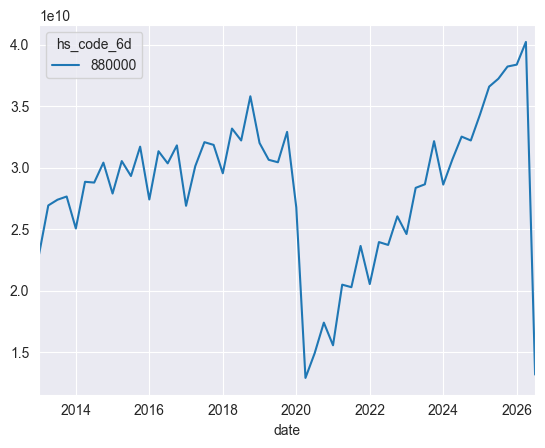

In [14]:
trade_pivot_df[['880000']].plot()

In [15]:
yoy_trade_growth[['841112']].tail(8)

hs_code_6d,841112
date,
2024-12-31,81.416354
2025-03-31,25.750799
2025-06-30,118.779000
2025-09-30,48.668200
2025-12-31,16.435559
2026-03-31,20.099922
2026-06-30,0.502814
2026-09-30,-62.242551
